# Balanceo de clases y PCA

El Sprint 0 estableció un baseline con 11 modelos sobre las 46 features geoquímicas originales, sin ningún tratamiento del desbalance de clases (IR ≈ 7:1). El **ganador baseline** fue XGBoost con F1\_CV = 0.7090.

En este sprint se abordan dos preguntas:

1. **¿El balanceo de clases mejora el F1?** Se evalúan 6 estrategias de sobremuestreo/combinadas (ROS, SMOTE, BorderlineSMOTE, ADASYN, SMOTETomek + sin balanceo) aplicadas **dentro de cada fold** del CV vía `ImbPipeline` de imblearn — esto garantiza que no haya fuga de información del fold de validación al proceso de balanceo.
2. **¿PCA ayuda a los modelos?** Se realiza un barrido exhaustivo de n=1..46 componentes × 11 modelos, sin balanceo y con el mejor balanceo de cada modelo. La hipótesis a verificar es si la reducción de dimensionalidad mejora la señal o si, por el contrario, los modelos basados en árboles de gradiente (que no se benefician de rotaciones ortogonales) prefieren las features originales con su semántica geoquímica intacta.

**Criterio de decisión:** F1\_CV 5-fold estratificada (misma métrica primaria del Sprint 0). El hold-out se evalúa una sola vez al final y solo con fines informativos.

## Configuración

In [1]:
import warnings, os, json, time, platform
from datetime import datetime
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_curve)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

# ── Directorios de salida (misma estructura que Sprint 0) ──
OUT = 'outputs_sprint1'
DIR_DATA    = f'{OUT}/data'
DIR_MODELS  = f'{OUT}/models'
DIR_FIG     = f'{OUT}/figures'
DIR_TAB     = f'{OUT}/tables'
for d in (OUT, DIR_DATA, DIR_MODELS, DIR_FIG, DIR_TAB):
    os.makedirs(d, exist_ok=True)

MODEL_COLORS = {
    'KNN': 'blue', 'Reg. Logística': 'orange', 'SVM (RBF)': 'teal', 'MLP': 'magenta',
    'Árbol de Decisión': 'green', 'Random Forest': 'darkred', 'ExtraTrees': 'olive',
    'HistGradientBoosting': 'brown', 'XGBoost': 'purple', 'LightGBM': 'darkcyan', 'CatBoost': 'goldenrod',
}
MODELOS = list(MODEL_COLORS.keys())

# ── Estilo de impresión ──
def coral(texto):
    '''Resalta texto en color coral para resultados clave.'''
    return f'\033[38;2;255;127;80m{texto}\033[0m'

print('Carpetas listas:', OUT)

Carpetas listas: outputs_sprint1


## Versiones de librerías

In [2]:
import sklearn, imblearn
versiones = {
    'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__,
    'scikit-learn': sklearn.__version__, 'imbalanced-learn': imblearn.__version__,
    'matplotlib': __import__('matplotlib').__version__, 'seaborn': sns.__version__,
    'joblib': joblib.__version__,
}
print('Versiones registradas:')
for k, v in versiones.items():
    print(f'  {k:18s}: {v}')

Versiones registradas:
  python            : 3.12.1
  numpy             : 2.4.6
  pandas            : 2.3.3
  scikit-learn      : 1.9.0
  imbalanced-learn  : 0.14.2
  matplotlib        : 3.11.0
  seaborn           : 0.13.2
  joblib            : 1.5.3


## Carga de artefactos del Sprint 0

Se cargan los artefactos persistidos por el Sprint 0: dataset procesado, índices del split train/test y el resumen con las métricas de referencia. **No se re-deriva el split ni se redefinen los modelos** — se reutilizan exactamente los mismos para garantizar la comparabilidad.

In [3]:
# ── Cargar resumen del Sprint 0 ──
with open('outputs_sprint0/resumen_sprint0.json') as f:
    RESUMEN_S0 = json.load(f)

F1_SPRINT0 = RESUMEN_S0['f1_final']
FEATURES   = RESUMEN_S0['features']

# ── Cargar dataset procesado ──
df = pd.read_csv('outputs_sprint0/data/data_procesada.csv')
X = df[FEATURES].copy()
y = df['target_Au'].astype(int).copy()

# ── Cargar índices del split (persistidos por S0) ──
idx_train = np.load('outputs_sprint0/data/idx_train.npy')
idx_test  = np.load('outputs_sprint0/data/idx_test.npy')
X_train, X_test = X.loc[idx_train], X.loc[idx_test]
y_train, y_test = y.loc[idx_train], y.loc[idx_test]

CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ── Verificación de integridad ──
assert X_train.shape[1] == len(FEATURES), f'Nº features no coincide: {X_train.shape[1]} vs {len(FEATURES)}'
assert len(X_train) + len(X_test) == len(df), 'Tamaño de split no coincide con dataset'

print(f'Modelos: {len(MODELOS)} | Features: {len(FEATURES)}')
print(f'Train: {X_train.shape} dist={y_train.value_counts().to_dict()}')
print(f'Test : {X_test.shape} dist={y_test.value_counts().to_dict()}')
print(coral(f'F1_CV ganador Sprint 0: {F1_SPRINT0:.4f} ({RESUMEN_S0["mejor_modelo"]})'))

Modelos: 11 | Features: 46
Train: (1705, 46) dist={0: 1497, 1: 208}
Test : (427, 46) dist={0: 375, 1: 52}
F1_CV ganador Sprint 0: 0.7090 (XGBoost)


## Funciones

Los clasificadores base se extraen directamente de los pipelines `.pkl` guardados por el Sprint 0 (`outputs_sprint0/models/`). La función `crear_clf()` carga el clasificador del pipeline persistido, garantizando que los hiperparámetros sean **exactamente** los mismos que produjeron el baseline.

El balanceo se aplica **dentro** de cada fold del CV 5-fold estratificado mediante `ImbPipeline` de imblearn. Esto evita fuga de información: los ejemplos sintéticos generados por SMOTE/ROS nunca contaminan el fold de validación.

In [4]:
# ── Cargar modelos del Sprint 0 ──
_modelos_s0 = {}
for nombre, ruta in RESUMEN_S0['modelos_guardados'].items():
    _modelos_s0[nombre] = joblib.load(ruta)
print(f'{len(_modelos_s0)} modelos cargados de outputs_sprint0/models/')

def crear_clf(mod):
    '''Extrae el clasificador base del pipeline S0 (sin scaler) y devuelve un clon fresco.'''
    from sklearn.base import clone
    pipe_s0 = _modelos_s0[mod]
    clf_original = pipe_s0.named_steps['clf']
    return clone(clf_original)

def crear_balanceador(nombre):
    '''Instancia el balanceador indicado. Devuelve None para "Sin balanceo".'''
    if nombre == 'Sin balanceo':      return None
    if nombre == 'RandomOverSampler': return RandomOverSampler(random_state=SEED)
    if nombre == 'SMOTE':             return SMOTE(random_state=SEED, k_neighbors=5)
    if nombre == 'BorderlineSMOTE':   return BorderlineSMOTE(random_state=SEED, k_neighbors=5)
    if nombre == 'ADASYN':            return ADASYN(random_state=SEED)
    if nombre == 'SMOTETomek':        return SMOTETomek(random_state=SEED)
    raise ValueError(nombre)

BALANCEADORES = ['Sin balanceo', 'RandomOverSampler', 'SMOTE', 'BorderlineSMOTE', 'ADASYN', 'SMOTETomek']

def construir_pipeline(mod, balanceo='Sin balanceo', n_pca=None):
    '''ImbPipeline: StandardScaler → (balanceo) → (PCA) → clasificador.
    Balanceo y PCA se reajustan DENTRO de cada fold de CV (sin fuga).'''
    pasos = [('sc', StandardScaler())]
    bal = crear_balanceador(balanceo)
    if bal is not None:
        pasos.append(('bal', bal))
    if n_pca is not None:
        pasos.append(('pca', PCA(n_components=n_pca, random_state=SEED)))
    pasos.append(('clf', crear_clf(mod)))
    return ImbPipeline(pasos)

def f1_cv(mod, balanceo='Sin balanceo', n_pca=None):
    '''MÉTRICA PRIMARIA: F1 clase positiva por CV 5-fold. Devuelve (media, std). NO toca hold-out.'''
    pipe = construir_pipeline(mod, balanceo, n_pca)
    sc = cross_val_score(pipe, X_train, y_train, cv=CV5, scoring='f1', n_jobs=-1)
    return sc.mean(), sc.std()

def scores_pos(pipe, Xte):
    '''Probabilidad de la clase positiva (o decision_function si no hay predict_proba).'''
    clf = pipe.named_steps['clf']
    if hasattr(clf, 'predict_proba'):
        return pipe.predict_proba(Xte)[:, 1]
    return pipe.decision_function(Xte)

def metricas_holdout(yte, y_pred, y_sco):
    '''Calcula métricas completas sobre hold-out (solo informativo).'''
    return {
        'F1':        f1_score(yte, y_pred),
        'Accuracy':  accuracy_score(yte, y_pred),
        'Precision': precision_score(yte, y_pred, zero_division=0),
        'Recall':    recall_score(yte, y_pred),
        'AUC-ROC':   roc_auc_score(yte, y_sco),
        'AUC-PR':    average_precision_score(yte, y_sco),
    }

def evaluar_holdout(mod, balanceo='Sin balanceo', n_pca=None):
    '''INFORMATIVO: entrena en train completo y evalúa en hold-out una sola vez.'''
    pipe = construir_pipeline(mod, balanceo, n_pca)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test); y_sco = scores_pos(pipe, X_test)
    m = metricas_holdout(y_test, y_pred, y_sco)
    m['_pred'] = y_pred; m['_score'] = y_sco; m['_pipe'] = pipe
    return m

def resaltar_maximo(s):
    '''Styler: resalta en coral el máximo de la serie.'''
    estilos = [''] * len(s)
    estilos[s.index.get_loc(s.idxmax())] = 'background-color: coral; color: white; font-weight: bold'
    return estilos

def resaltar_maximo_fila(s):
    '''Styler: resalta en coral el máximo de cada fila.'''
    estilos = [''] * len(s)
    estilos[s.index.get_loc(s.idxmax())] = 'background-color: coral; color: white; font-weight: bold'
    return estilos

print('Funciones listas')

11 modelos cargados de outputs_sprint0/models/
Funciones listas


## Verificación del baseline

Antes de evaluar balanceo y PCA, se verifica que el F1\_CV del modelo ganador del Sprint 0 se reproduce **exactamente** con los artefactos cargados. Esto garantiza que el split y los hiperparámetros son idénticos.

In [8]:
# ── Verificar reproducción exacta del F1_CV del Sprint 0 ──
f1_check, _ = f1_cv(RESUMEN_S0['mejor_modelo'])
delta = abs(f1_check - F1_SPRINT0)
print(f'F1_CV reproducido ({RESUMEN_S0["mejor_modelo"]}): {f1_check:.4f}')
print(f'F1_CV Sprint 0:              {F1_SPRINT0:.4f}')
print(coral(f'Δ = {delta:.6f} ({"Reproducción exacta" if delta < 1e-4 else "DISCREPANCIA"})'))
assert delta < 1e-4, f'ERROR: F1_CV no se reproduce (Δ={delta:.6f})'

F1_CV reproducido (XGBoost): 0.7090
F1_CV Sprint 0:              0.7090
Δ = 0.000029 (Reproducción exacta)


## Balanceo de clases

Se evalúan 6 estrategias de balanceo para cada uno de los 11 modelos. El balanceo se aplica **dentro** de cada fold del CV 5-fold (vía `ImbPipeline`), asegurando que:

- Los ejemplos sintéticos de SMOTE y variantes se generan solo con datos del fold de entrenamiento.
- El fold de validación contiene solo datos reales, sin contaminación.

**¿Por qué no se usa `class_weight` en vez de sobremuestreo?** En este sprint se estudia el efecto del sobremuestreo como **técnica complementaria** — aplicable a cualquier modelo, no solo a los que soportan pesos de clase. Esto permite una comparación homogénea entre los 11 modelos.

**Nota sobre SMOTE en geoquímica:** SMOTE genera ejemplos sintéticos por interpolación lineal entre vecinos. En datos composicionales (geoquímicos), la interpolación lineal puede producir composiciones irreales (p. ej. sumando a más de 100%). Sin embargo, para elementos traza en ppm (no porcentajes) este riesgo es menor. Se reportan los resultados de todas las técnicas para transparencia.

In [9]:
print('Evaluando 6 métodos de balanceo × 11 modelos por F1_CV ...')
t0_bal = time.time()
f1_bal = pd.DataFrame(index=BALANCEADORES, columns=MODELOS, dtype=float)
f1_bal_std = pd.DataFrame(index=BALANCEADORES, columns=MODELOS, dtype=float)
for bal in BALANCEADORES:
    for mod in MODELOS:
        mu, sd = f1_cv(mod, balanceo=bal)
        f1_bal.loc[bal, mod] = mu; f1_bal_std.loc[bal, mod] = sd
    print(f'  {bal} completado')
print(f'Balanceo terminado en {time.time()-t0_bal:.0f}s')

f1_bal = f1_bal.astype(float).round(4)
f1_bal_std = f1_bal_std.astype(float).round(4)
f1_bal.to_csv(f'{DIR_TAB}/balanceo_f1_cv.csv')
f1_bal_std.to_csv(f'{DIR_TAB}/balanceo_f1_cv_std.csv')

print('\nBalanceo — F1_CV (media) por método y modelo · MÉTRICA PRIMARIA')
f1_bal.style.apply(resaltar_maximo, axis=0).format('{:.4f}')

Evaluando 6 métodos de balanceo × 11 modelos por F1_CV ...
  Sin balanceo completado
  RandomOverSampler completado
  SMOTE completado
  BorderlineSMOTE completado
  ADASYN completado
  SMOTETomek completado
Balanceo terminado en 229s

Balanceo — F1_CV (media) por método y modelo · MÉTRICA PRIMARIA


,KNN,Reg. Logística,SVM (RBF),MLP,Árbol de Decisión,Random Forest,ExtraTrees,HistGradientBoosting,XGBoost,LightGBM,CatBoost
Sin balanceo,0.4357,0.5493,0.4312,0.6413,0.5448,0.6501,0.5881,0.7034,0.7090,0.6937,0.6671
RandomOverSampler,0.4876,0.5190,0.4478,0.6414,0.5342,0.6619,0.4552,0.7226,0.7201,0.7019,0.7277
SMOTE,0.4730,0.5118,0.4500,0.6236,0.5528,0.6831,0.6498,0.6918,0.6925,0.7201,0.6949
BorderlineSMOTE,0.4704,0.5050,0.4449,0.6398,0.5701,0.6579,0.6381,0.7187,0.6834,0.7101,0.6923
ADASYN,0.4679,0.4951,0.4250,0.6436,0.5123,0.6594,0.6377,0.7050,0.6987,0.6887,0.6619
SMOTETomek,0.4730,0.5153,0.4494,0.6318,0.5601,0.6739,0.6438,0.7082,0.7075,0.7245,0.6876


In [10]:
mejor_bal_por_modelo = {mod: f1_bal[mod].idxmax() for mod in MODELOS}
resumen_bal = pd.DataFrame({
    'Mejor método':      [mejor_bal_por_modelo[m] for m in MODELOS],
    'F1_CV (mejor)':     [round(f1_bal[m].max(), 4) for m in MODELOS],
    'F1_CV (sin bal.)':  [round(f1_bal.loc['Sin balanceo', m], 4) for m in MODELOS],
}, index=MODELOS)
resumen_bal['Δ F1_CV'] = (resumen_bal['F1_CV (mejor)'] - resumen_bal['F1_CV (sin bal.)']).round(4)
resumen_bal.to_csv(f'{DIR_TAB}/balanceo_mejor_por_modelo.csv')

print('Mejor método de balanceo por modelo (por F1_CV):')
resumen_bal

Mejor método de balanceo por modelo (por F1_CV):


,Mejor método,F1_CV (mejor),F1_CV (sin bal.),Δ F1_CV
KNN,RandomOverSampler,0.4876,0.4357,0.0519
Reg. Logística,Sin balanceo,0.5493,0.5493,0.0000
SVM (RBF),SMOTE,0.4500,0.4312,0.0188
MLP,ADASYN,0.6436,0.6413,0.0023
Árbol de Decisión,BorderlineSMOTE,0.5701,0.5448,0.0253
Random Forest,SMOTE,0.6831,0.6501,0.0330
ExtraTrees,SMOTE,0.6498,0.5881,0.0617
HistGradientBoosting,RandomOverSampler,0.7226,0.7034,0.0192
XGBoost,RandomOverSampler,0.7201,0.7090,0.0111
LightGBM,SMOTETomek,0.7245,0.6937,0.0308


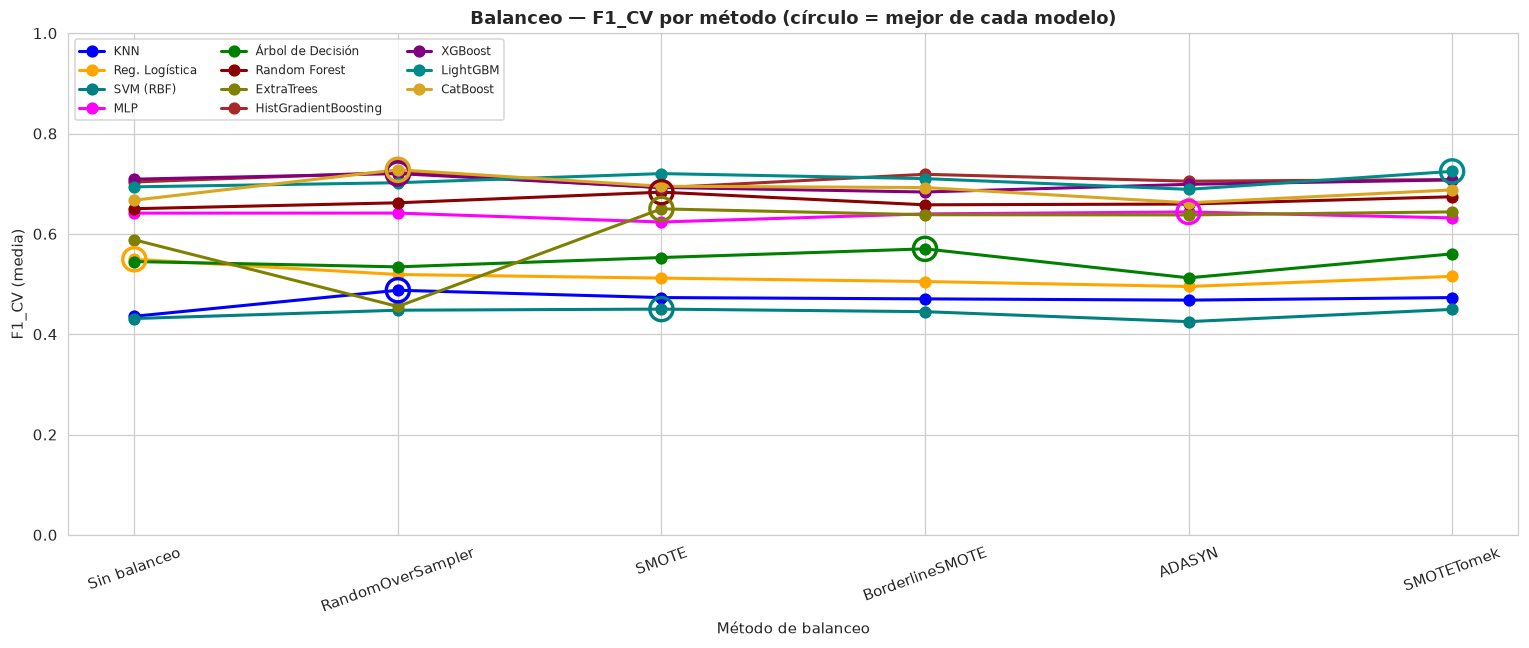

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(BALANCEADORES))
for mod in MODELOS:
    ax.plot(x, f1_bal[mod].values, marker='o', lw=2, markersize=7, color=MODEL_COLORS[mod], label=mod)
    xi = BALANCEADORES.index(mejor_bal_por_modelo[mod])
    ax.scatter([xi], [f1_bal.loc[mejor_bal_por_modelo[mod], mod]], s=230, facecolors='none',
               edgecolors=MODEL_COLORS[mod], linewidths=2.2, zorder=5)
ax.set_xticks(x); ax.set_xticklabels(BALANCEADORES, rotation=20)
ax.set_xlabel('Método de balanceo'); ax.set_ylabel('F1_CV (media)'); ax.set_ylim(0, 1)
ax.set_title('Balanceo — F1_CV por método (círculo = mejor de cada modelo)', fontweight='bold')
ax.legend(fontsize=8, ncol=3, loc='upper left')
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/balanceo_f1_cv_comparacion.png', bbox_inches='tight'); plt.show()

## Análisis de Componentes Principales (PCA)

Se evalúa si la reducción de dimensionalidad mediante PCA mejora el F1\_CV de alguno de los 11 modelos. Se realiza un **barrido exhaustivo** de n=1..46 componentes para cada modelo, en dos escenarios:

1. **PCA sin balanceo (E1):** PCA sobre los datos originales escalados.
2. **PCA con el mejor balanceo de cada modelo (E2):** PCA sobre los datos balanceados con el método ganador de cada modelo (sección anterior).

El PCA se aplica **dentro** del pipeline (después del scaler y del balanceo), recalculándose en cada fold del CV para evitar fuga de información.

**Hipótesis:** los modelos basados en árboles de gradiente (XGBoost, LightGBM, CatBoost, HGB) no deberían beneficiarse de PCA, porque los árboles particionan por umbrales sobre features individuales — la rotación ortogonal de PCA destruye la semántica de los elementos geoquímicos.

In [12]:
def sustento_pca(Xtr_scaled):
    '''Descriptivo: var_acum, eigenvalues y umbrales n80/n90/n95/kaiser.'''
    pca = PCA(random_state=SEED).fit(Xtr_scaled)
    var_acum = np.cumsum(pca.explained_variance_ratio_)
    eigen = pca.explained_variance_
    n = {u: int(np.argmax(var_acum >= u)+1) for u in (.80, .90, .95)}
    n['kaiser'] = int(np.sum(eigen > 1))
    return var_acum, eigen, n

def graficar_sustento(var_acum, eigen, n, titulo, fname):
    '''Gráficos de varianza acumulada y scree plot con umbrales Kaiser/80/90/95%.'''
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    comp = np.arange(1, len(var_acum)+1)
    axes[0].plot(comp, var_acum, marker='o', ms=3, color='blue', lw=1.6)
    for u, c in [(.80, 'green'), (.90, 'orange'), (.95, 'red')]:
        axes[0].axhline(u, ls='--', color=c, alpha=.7); axes[0].axvline(n[u], ls=':', color=c, alpha=.7)
        axes[0].text(n[u]+0.3, u-0.06, f'{int(u*100)}% → {n[u]}', color=c, fontweight='bold', fontsize=9)
    axes[0].set_xlabel('Nº componentes'); axes[0].set_ylabel('Varianza explicada acumulada')
    axes[0].set_title(f'Varianza acumulada — {titulo}', fontweight='bold')
    axes[1].plot(comp, eigen, marker='o', ms=3, color='purple', lw=1.5)
    axes[1].axhline(1.0, ls='--', color='red', label='Kaiser (eigenvalue=1)')
    axes[1].axvline(n['kaiser'], ls=':', color='red', alpha=.7)
    axes[1].text(n['kaiser']+0.3, max(eigen)*0.6, f"Kaiser → {n['kaiser']}", color='red', fontweight='bold', fontsize=9)
    axes[1].set_xlabel('Nº componentes'); axes[1].set_ylabel('Eigenvalue')
    axes[1].set_title(f'Scree plot + Kaiser — {titulo}', fontweight='bold'); axes[1].legend()
    plt.tight_layout(); plt.savefig(fname, bbox_inches='tight'); plt.show()

N_FEATURES = len(FEATURES)

def barrido_pca_cv(balanceo_por_modelo):
    '''F1_CV para n=1..N_FEATURES y cada modelo, con el balanceo indicado por modelo.'''
    tab = pd.DataFrame(index=range(1, N_FEATURES+1), columns=MODELOS, dtype=float)
    for mod in MODELOS:
        bal = balanceo_por_modelo if isinstance(balanceo_por_modelo, str) else balanceo_por_modelo[mod]
        for n in range(1, N_FEATURES+1):
            mu, _ = f1_cv(mod, balanceo=bal, n_pca=n)
            tab.loc[n, mod] = mu
    return tab.astype(float).round(4)

def top5_por_modelo(tab, etiqueta):
    '''Extrae los 5 mejores n_componentes por modelo.'''
    filas = []
    for mod in MODELOS:
        top = tab[mod].sort_values(ascending=False).head(5)
        for rank, (n, f1) in enumerate(top.items(), 1):
            filas.append({'Modelo': mod, 'Escenario': etiqueta, 'Rank': rank, 'n_comp': int(n), 'F1_CV': f1})
    return pd.DataFrame(filas)

def grafico_barrido(tab, titulo, fname):
    '''Gráfico de F1_CV vs Nº componentes PCA para los 11 modelos.'''
    fig, ax = plt.subplots(figsize=(14, 6))
    for mod in MODELOS:
        ax.plot(tab.index, tab[mod], marker='o', ms=3, lw=1.7, color=MODEL_COLORS[mod], label=mod)
        n_best = int(tab[mod].idxmax())
        ax.scatter([n_best], [tab[mod].max()], s=200, facecolors='none',
                   edgecolors=MODEL_COLORS[mod], linewidths=2.2, zorder=5)
    ax.set_xlabel(f'Nº de componentes PCA (1–{N_FEATURES})'); ax.set_ylabel('F1_CV (media)')
    ax.set_title(titulo, fontweight='bold'); ax.set_xlim(0, N_FEATURES+1); ax.set_ylim(0, 1)
    ax.legend(fontsize=8, ncol=3)
    plt.tight_layout(); plt.savefig(fname, bbox_inches='tight'); plt.show()
print('Funciones de PCA listas.')

Funciones de PCA listas.


### PCA sin balanceo (E1)

PCA (sin balanceo) → Kaiser=13 | 80%=14 | 90%=22 | 95%=28


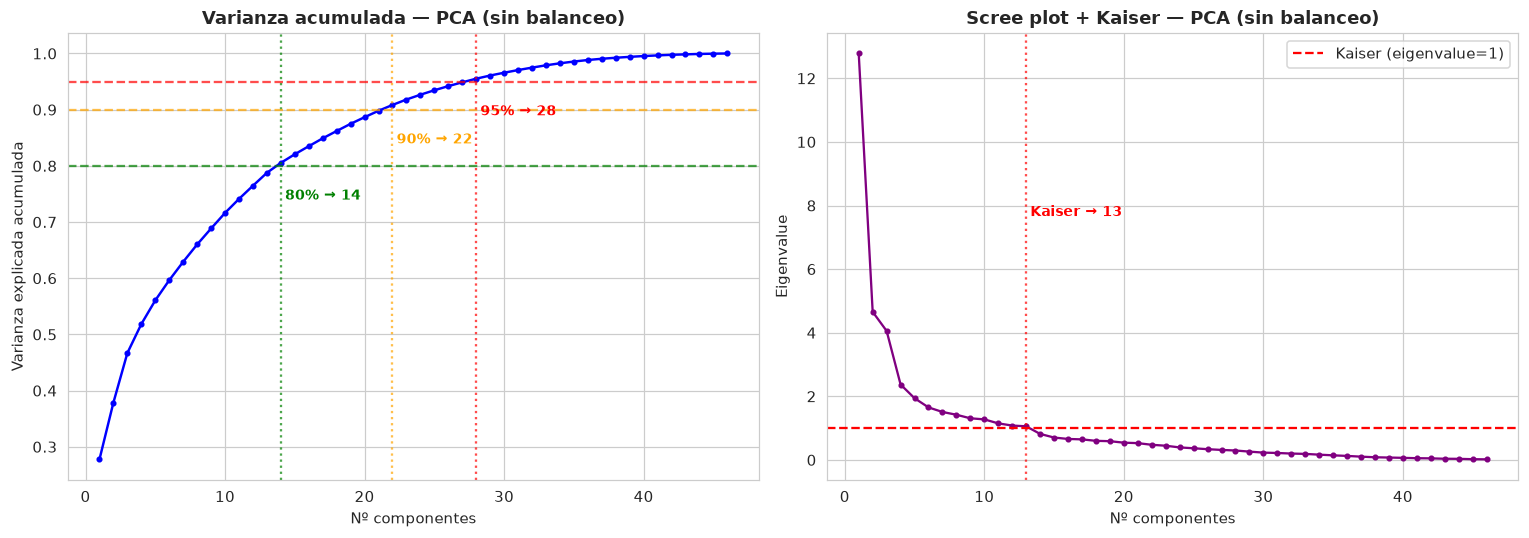

In [13]:
sc0 = StandardScaler().fit(X_train)
va0, eig0, n0 = sustento_pca(sc0.transform(X_train))
print(f"PCA (sin balanceo) → Kaiser={n0['kaiser']} | 80%={n0[.80]} | 90%={n0[.90]} | 95%={n0[.95]}")
graficar_sustento(va0, eig0, n0, 'PCA (sin balanceo)', f'{DIR_FIG}/PCA_sinbalanceo.png')

Barrido PCA E1 (sin balanceo) por F1_CV ...
  hecho en 880s


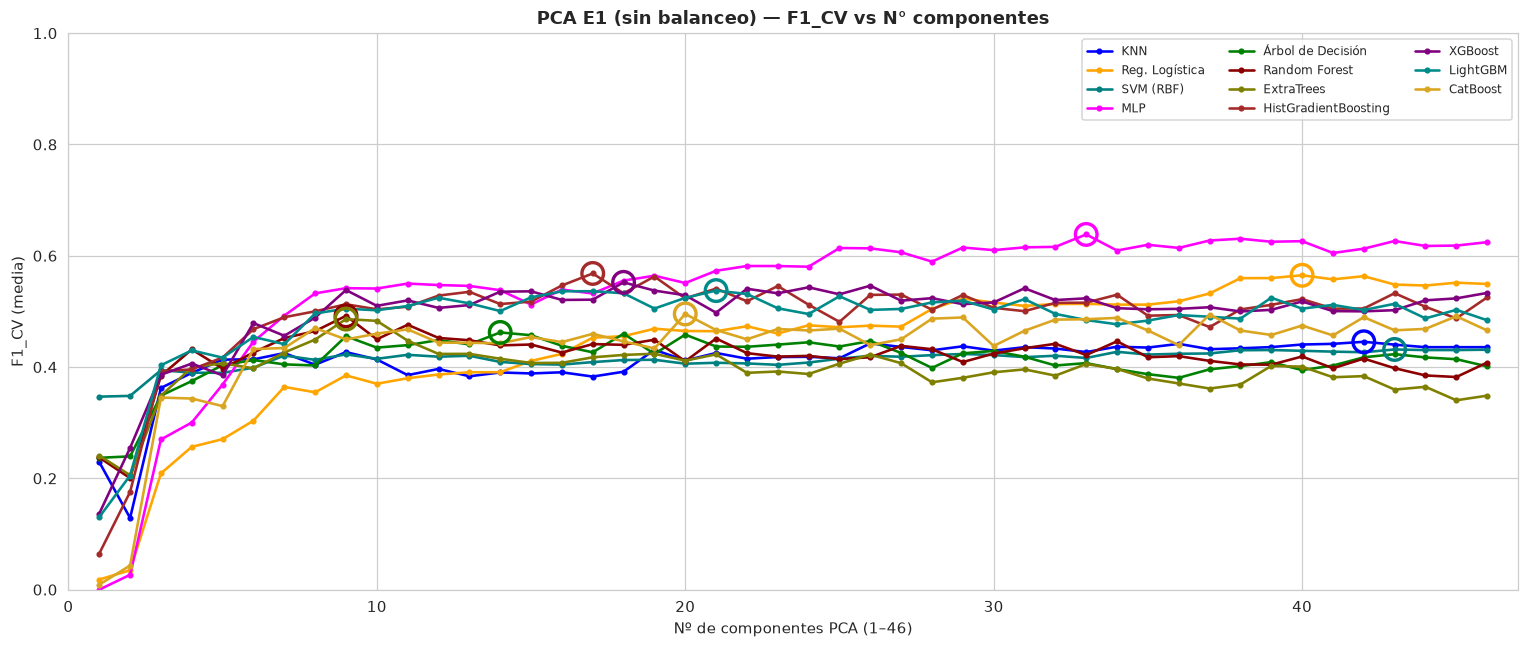

In [14]:
print('Barrido PCA E1 (sin balanceo) por F1_CV ...')
t0 = time.time()
tab_pca_e1 = barrido_pca_cv('Sin balanceo')
print(f'  hecho en {time.time()-t0:.0f}s')
tab_pca_e1.to_csv(f'{DIR_TAB}/PCA_sinbalanceo_f1_cv.csv')
grafico_barrido(tab_pca_e1, 'PCA E1 (sin balanceo) — F1_CV vs N° componentes',
                f'{DIR_FIG}/PCA_sinbalanceo_comparacion_f1_cv.png')

In [15]:
top5_e1 = top5_por_modelo(tab_pca_e1, 'PCA sin balanceo')
top5_e1.to_csv(f'{DIR_TAB}/PCA_sinbalanceo_top5.csv', index=False)
print('Top-5 (n_comp | F1_CV) por modelo — PCA E1 (sin balanceo):')
top5_e1.assign(comp_F1=lambda d: d['n_comp'].astype(str)+'  ('+d['F1_CV'].map('{:.3f}'.format)+')')\
       .pivot(index='Rank', columns='Modelo', values='comp_F1')

Top-5 (n_comp | F1_CV) por modelo — PCA E1 (sin balanceo):


Modelo,CatBoost,ExtraTrees,HistGradientBoosting,KNN,LightGBM,MLP,Random Forest,Reg. Logística,SVM (RBF),XGBoost,Árbol de Decisión
Rank,,,,,,,,,,,
1,20 (0.495),9 (0.486),17 (0.568),42 (0.445),21 (0.537),33 (0.638),9 (0.492),40 (0.565),43 (0.432),18 (0.552),14 (0.462)
2,37 (0.494),10 (0.483),19 (0.563),26 (0.443),17 (0.536),38 (0.631),11 (0.476),42 (0.563),46 (0.431),26 (0.546),18 (0.460)
3,45 (0.491),8 (0.449),16 (0.547),41 (0.442),16 (0.536),37 (0.627),8 (0.465),39 (0.560),39 (0.431),24 (0.543),20 (0.458)
4,42 (0.490),11 (0.447),23 (0.546),36 (0.442),18 (0.533),43 (0.626),12 (0.452),38 (0.560),44 (0.430),31 (0.542),15 (0.457)
5,29 (0.489),7 (0.426),21 (0.541),40 (0.441),22 (0.531),40 (0.626),7 (0.452),41 (0.558),45 (0.430),22 (0.541),9 (0.455)


### PCA con el mejor balanceo de cada modelo (E2)

Mejor balanceo por modelo: {'KNN': 'RandomOverSampler', 'Reg. Logística': 'Sin balanceo', 'SVM (RBF)': 'SMOTE', 'MLP': 'ADASYN', 'Árbol de Decisión': 'BorderlineSMOTE', 'Random Forest': 'SMOTE', 'ExtraTrees': 'SMOTE', 'HistGradientBoosting': 'RandomOverSampler', 'XGBoost': 'RandomOverSampler', 'LightGBM': 'SMOTETomek', 'CatBoost': 'RandomOverSampler'}
Métodos únicos a sustentar en PCA: ['ADASYN', 'BorderlineSMOTE', 'RandomOverSampler', 'SMOTE', 'SMOTETomek', 'Sin balanceo']


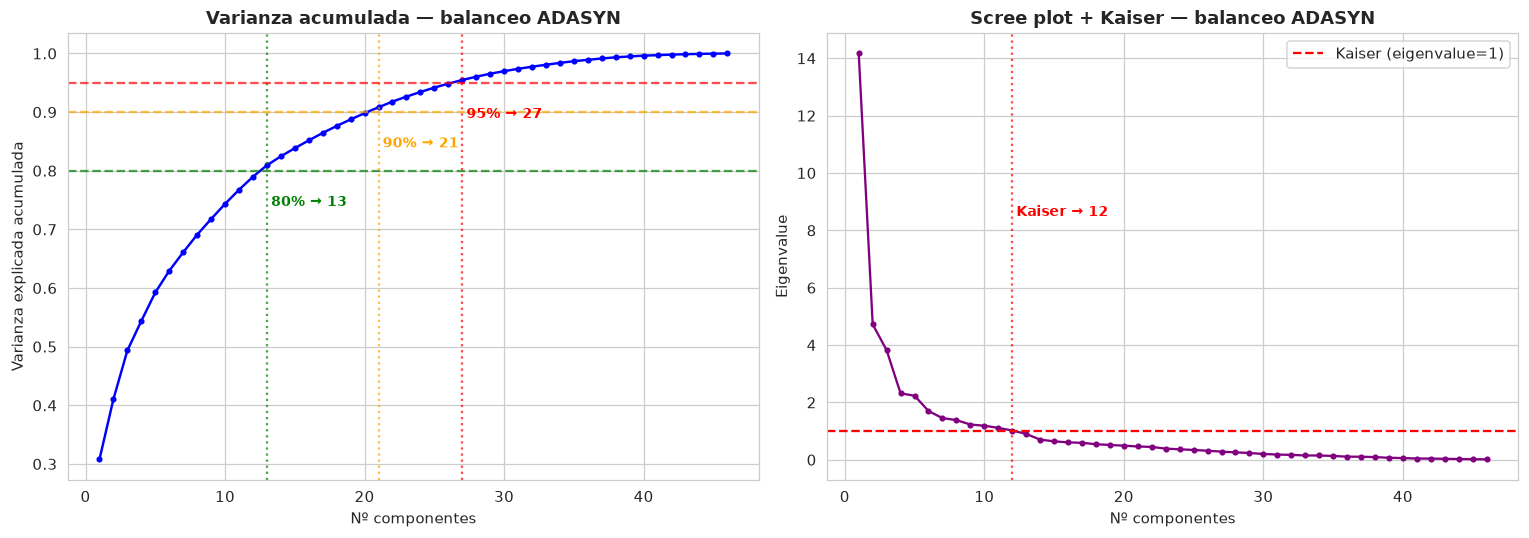

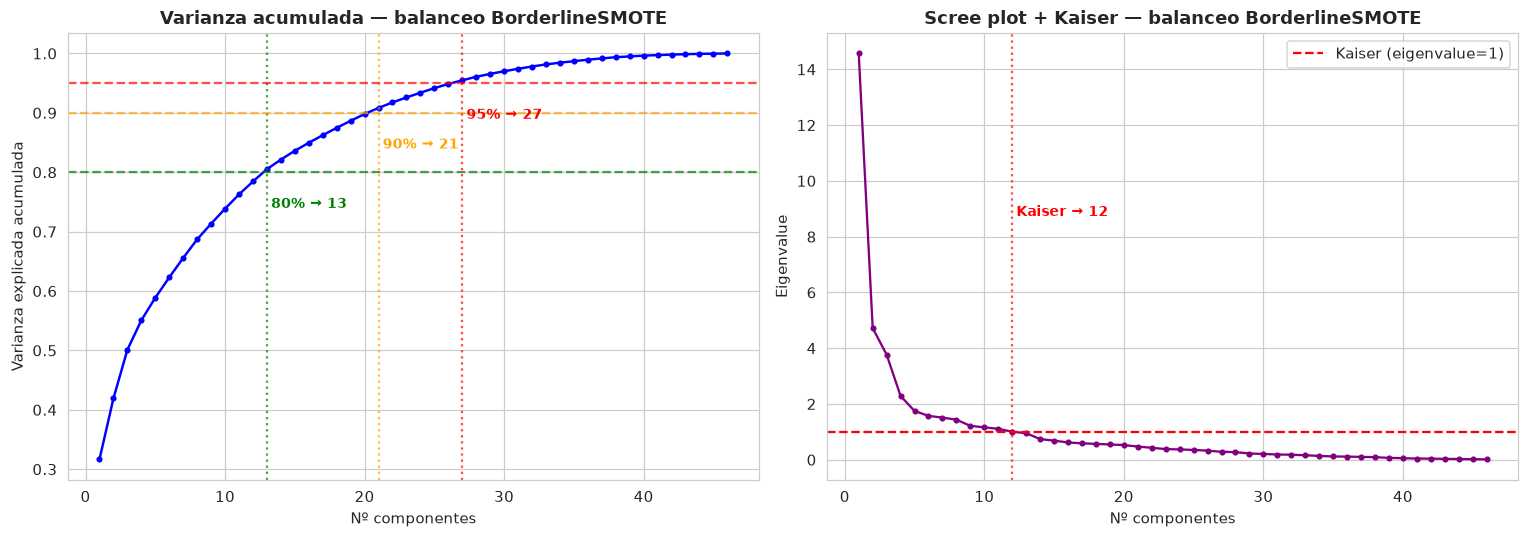

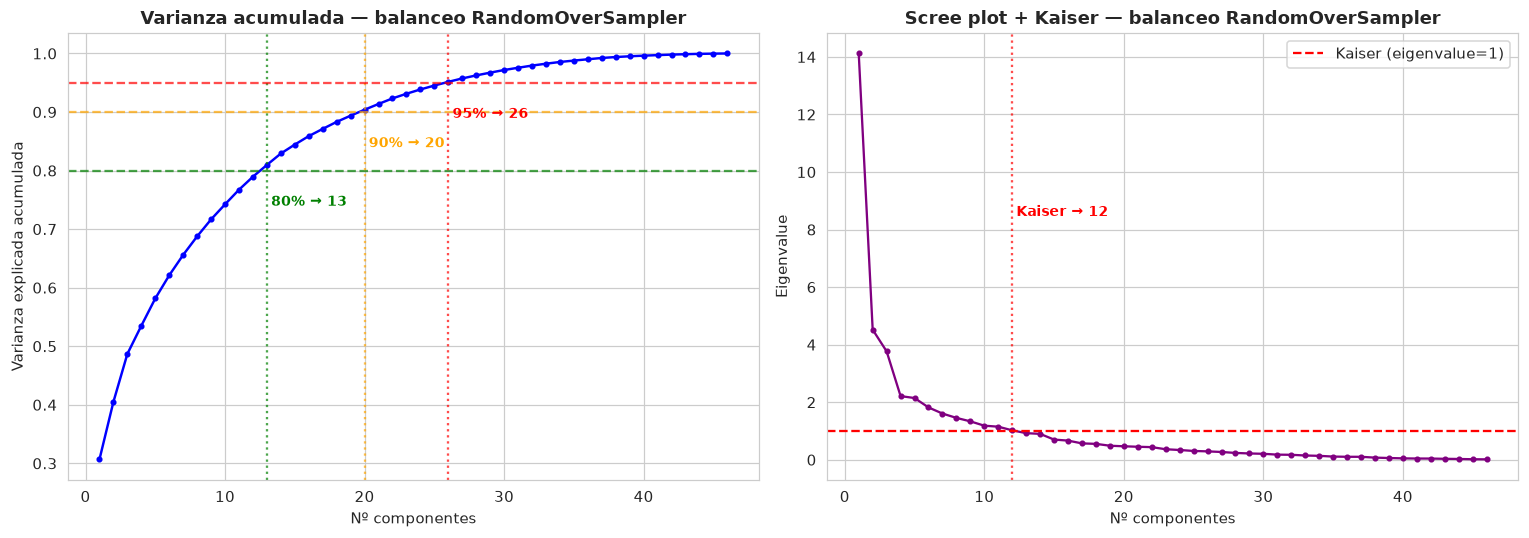

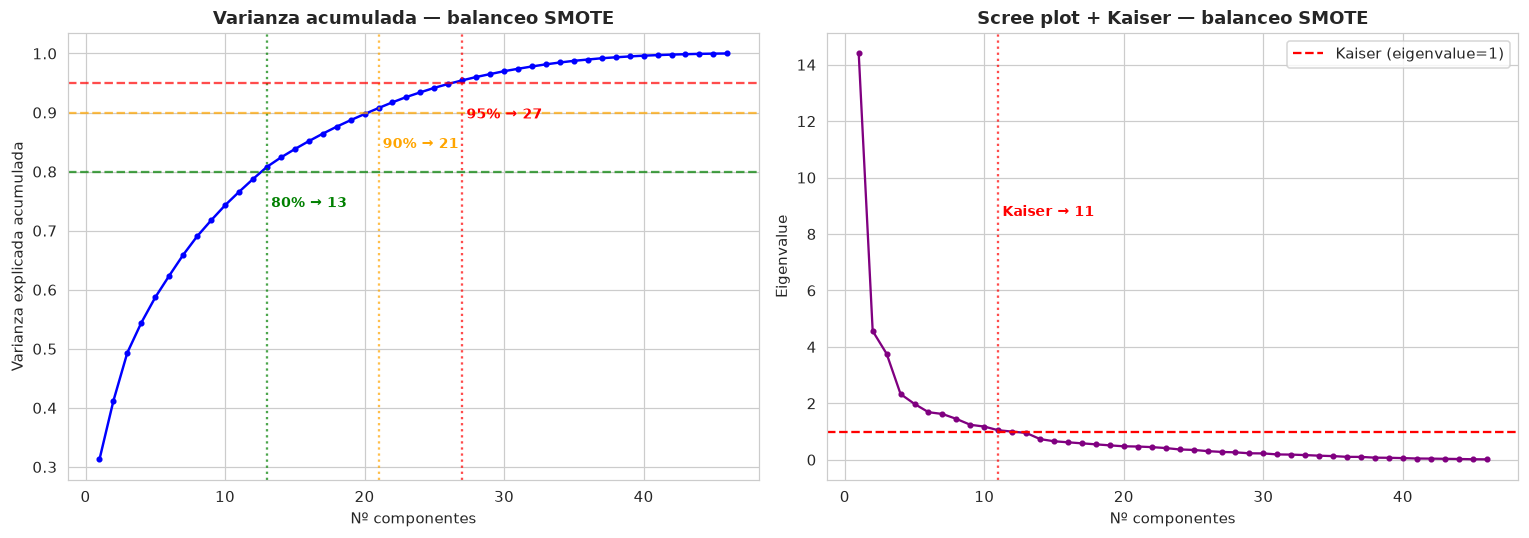

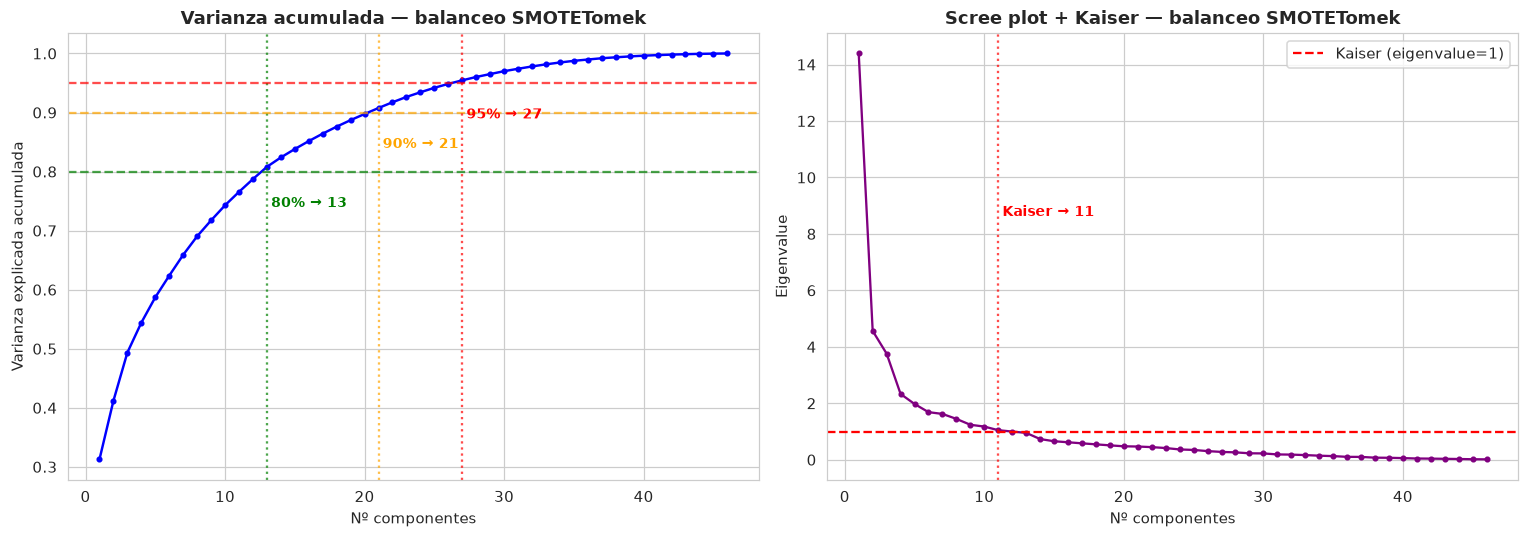

Umbrales de componentes por escenario/balanceo (descriptivo):


,Balanceo,Kaiser,80%,90%,95%
0,Sin balanceo,13,14,22,28
1,ADASYN,12,13,21,27
2,BorderlineSMOTE,12,13,21,27
3,RandomOverSampler,12,13,20,26
4,SMOTE,11,13,21,27
5,SMOTETomek,11,13,21,27


In [16]:
metodos_unicos = sorted(set(mejor_bal_por_modelo.values()))
print('Mejor balanceo por modelo:', mejor_bal_por_modelo)
print('Métodos únicos a sustentar en PCA:', metodos_unicos)

filas_umbral = [{'Balanceo': 'Sin balanceo', 'Kaiser': n0['kaiser'], '80%': n0[.80], '90%': n0[.90], '95%': n0[.95]}]
for met in metodos_unicos:
    if met == 'Sin balanceo':
        continue
    bal = crear_balanceador(met)
    Xb, yb = bal.fit_resample(X_train, y_train)
    va, eig, nn = sustento_pca(StandardScaler().fit(Xb).transform(Xb))
    filas_umbral.append({'Balanceo': met, 'Kaiser': nn['kaiser'], '80%': nn[.80], '90%': nn[.90], '95%': nn[.95]})
    graficar_sustento(va, eig, nn, f'balanceo {met}', f'{DIR_FIG}/PCA_conbalanceo_{met}.png')
tabla_umbrales = pd.DataFrame(filas_umbral)
tabla_umbrales.to_csv(f'{DIR_TAB}/PCA_conbalanceo_umbrales.csv', index=False)
print('Umbrales de componentes por escenario/balanceo (descriptivo):')
tabla_umbrales

Barrido PCA E2 (con mejor balanceo por modelo) por F1_CV ...
  hecho en 1267s


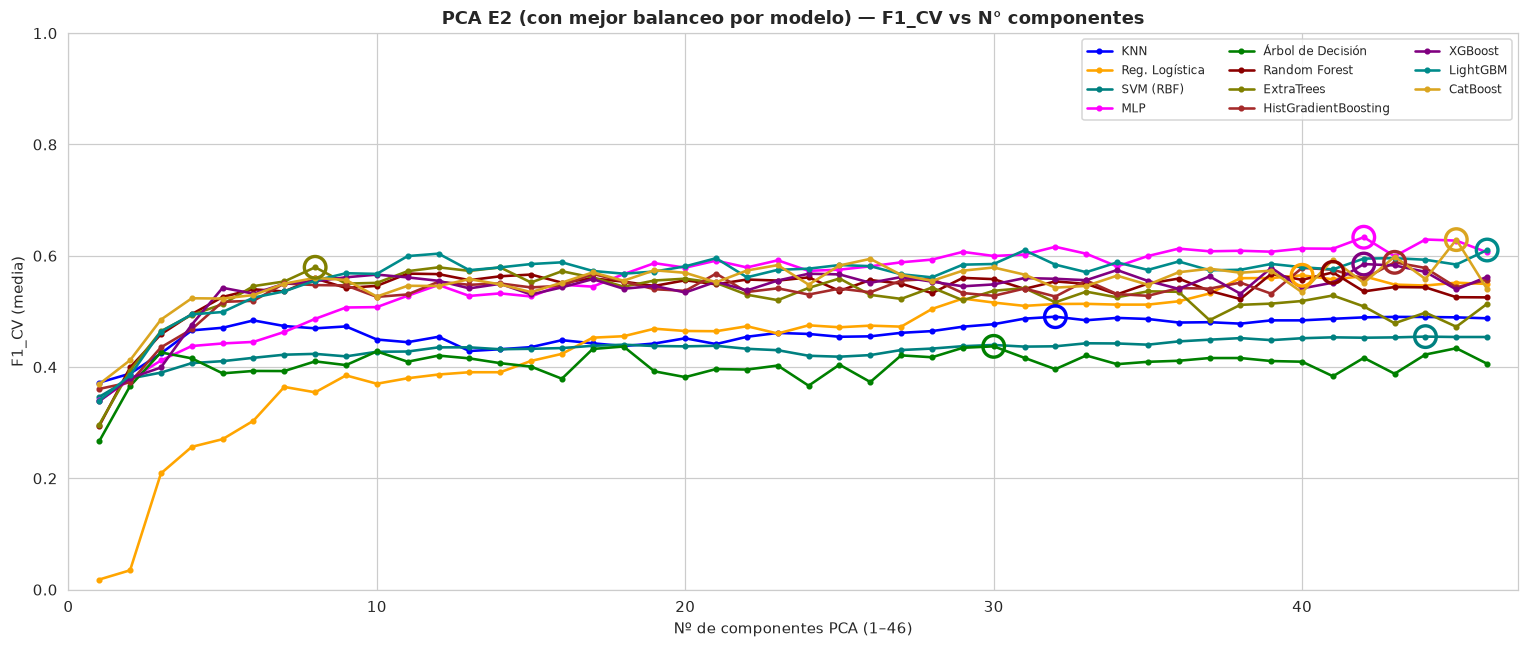

In [17]:
print('Barrido PCA E2 (con mejor balanceo por modelo) por F1_CV ...')
t0 = time.time()
tab_pca_e2 = barrido_pca_cv(mejor_bal_por_modelo)
print(f'  hecho en {time.time()-t0:.0f}s')
tab_pca_e2.to_csv(f'{DIR_TAB}/PCA_conbalanceo_f1_cv.csv')
grafico_barrido(tab_pca_e2, 'PCA E2 (con mejor balanceo por modelo) — F1_CV vs N° componentes',
                f'{DIR_FIG}/PCA_conbalanceo_comparacion_f1_cv.png')

## Comparativo final

Se comparan 4 configuraciones para cada modelo, todas decididas por F1\_CV:

| Config | Descripción |
|---|---|
| (1) Baseline | Sprint 0: sin balanceo, sin PCA |
| (2) Balanceo | Mejor método de balanceo del barrido anterior |
| (3) PCA | Mejor n\_componentes sin balanceo |
| (4) Bal+PCA | Mejor n\_componentes con el mejor balanceo |

La configuración ganadora de cada modelo se selecciona como la de mayor F1\_CV. Si el balanceo mejora y PCA no, la conclusión será que **las features originales con su semántica geoquímica son más informativas que las componentes principales abstractas**.

In [18]:
filas_f1 = {}
detalle = {}
for mod in MODELOS:
    met = mejor_bal_por_modelo[mod]
    n3 = int(tab_pca_e1[mod].idxmax())
    n4 = int(tab_pca_e2[mod].idxmax())
    f1_base, _  = f1_cv(mod, balanceo='Sin balanceo')
    f1_bal_v, _ = f1_cv(mod, balanceo=met)
    f1_pca, _   = f1_cv(mod, balanceo='Sin balanceo', n_pca=n3)
    f1_bp, _    = f1_cv(mod, balanceo=met, n_pca=n4)
    filas_f1[mod] = {'(1) Baseline': round(f1_base, 4), '(2) Balanceo': round(f1_bal_v, 4),
                     '(3) PCA': round(f1_pca, 4), '(4) Bal+PCA': round(f1_bp, 4)}
    detalle[mod] = {'_meta': {'metodo': met, 'n_pca_solo': n3, 'n_pca_bal': n4},
                    'config_kwargs': {'(1) Baseline': dict(balanceo='Sin balanceo', n_pca=None),
                                      '(2) Balanceo': dict(balanceo=met, n_pca=None),
                                      '(3) PCA': dict(balanceo='Sin balanceo', n_pca=n3),
                                      '(4) Bal+PCA': dict(balanceo=met, n_pca=n4)}}
print('Configuraciones evaluadas por F1_CV.')
for mod in MODELOS:
    mt = detalle[mod]['_meta']
    print(f"  {mod}: balanceo={mt['metodo']} | PCA solo={mt['n_pca_solo']}c | Bal+PCA={mt['n_pca_bal']}c")

Configuraciones evaluadas por F1_CV.
  KNN: balanceo=RandomOverSampler | PCA solo=42c | Bal+PCA=32c
  Reg. Logística: balanceo=Sin balanceo | PCA solo=40c | Bal+PCA=40c
  SVM (RBF): balanceo=SMOTE | PCA solo=43c | Bal+PCA=44c
  MLP: balanceo=ADASYN | PCA solo=33c | Bal+PCA=42c
  Árbol de Decisión: balanceo=BorderlineSMOTE | PCA solo=14c | Bal+PCA=30c
  Random Forest: balanceo=SMOTE | PCA solo=9c | Bal+PCA=41c
  ExtraTrees: balanceo=SMOTE | PCA solo=9c | Bal+PCA=8c
  HistGradientBoosting: balanceo=RandomOverSampler | PCA solo=17c | Bal+PCA=43c
  XGBoost: balanceo=RandomOverSampler | PCA solo=18c | Bal+PCA=42c
  LightGBM: balanceo=SMOTETomek | PCA solo=21c | Bal+PCA=46c
  CatBoost: balanceo=RandomOverSampler | PCA solo=20c | Bal+PCA=45c


In [19]:
tab_f1_evol = pd.DataFrame(filas_f1).T.round(4)
tab_f1_evol.to_csv(f'{DIR_TAB}/final_evolucion_f1_cv.csv')

print('Evolución de F1_CV por configuración (decisión):')
tab_f1_evol.style.apply(resaltar_maximo_fila, axis=1).format('{:.4f}')

Evolución de F1_CV por configuración (decisión):


,(1) Baseline,(2) Balanceo,(3) PCA,(4) Bal+PCA
KNN,0.4357,0.4876,0.4454,0.4905
Reg. Logística,0.5493,0.5493,0.5649,0.5649
SVM (RBF),0.4312,0.4500,0.4316,0.4547
MLP,0.6413,0.6436,0.6383,0.6333
Árbol de Decisión,0.5448,0.5701,0.4622,0.4372
Random Forest,0.6501,0.6831,0.4920,0.5701
ExtraTrees,0.5881,0.6498,0.4862,0.5793
HistGradientBoosting,0.7034,0.7226,0.5682,0.5882
XGBoost,0.7090,0.7201,0.5522,0.5851
LightGBM,0.6937,0.7245,0.5374,0.6103


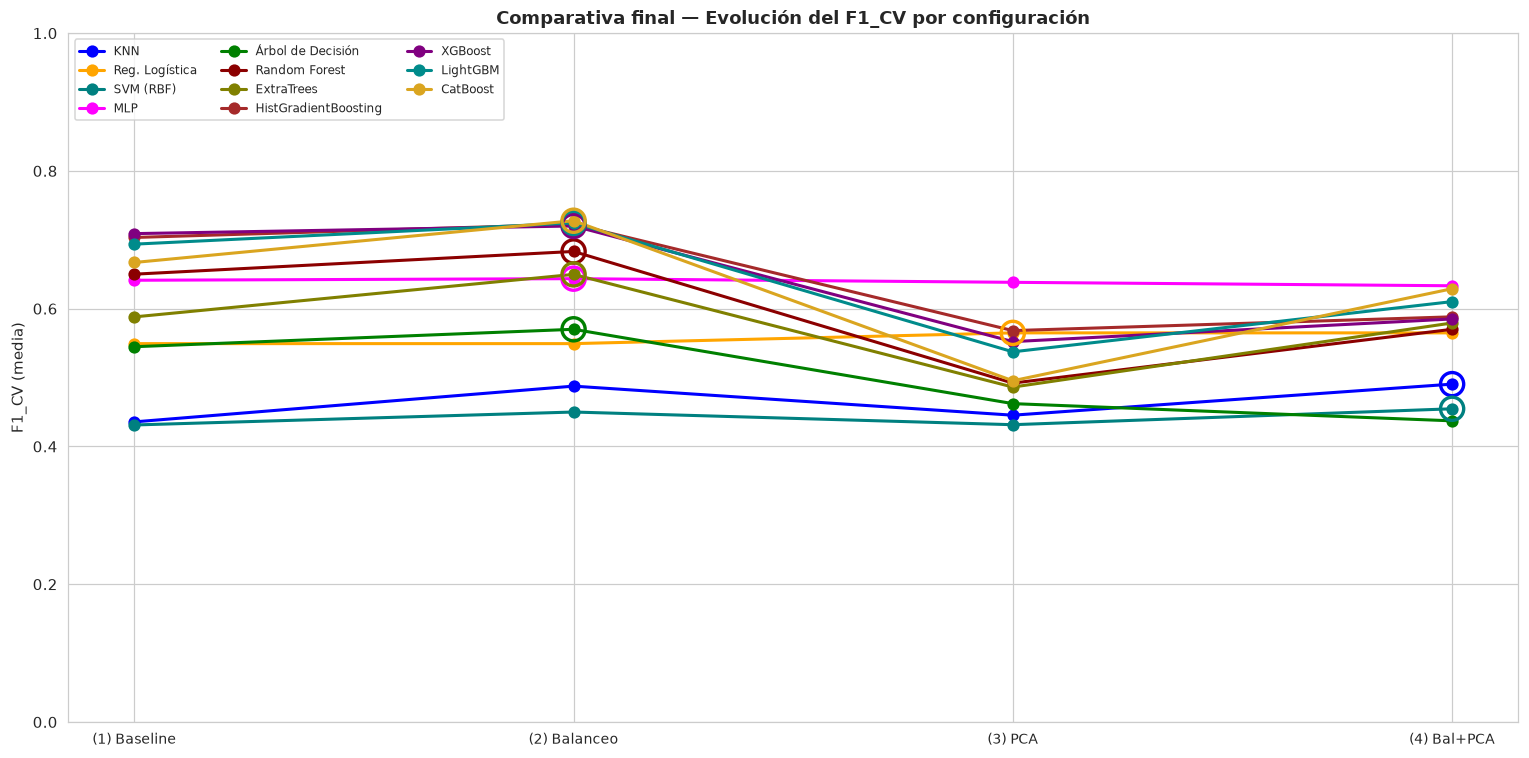

In [20]:
fig, ax = plt.subplots(figsize=(14, 7))
configs = list(next(iter(filas_f1.values())).keys())
x = np.arange(len(configs))
for mod in MODELOS:
    vals = [filas_f1[mod][c] for c in configs]
    ax.plot(x, vals, marker='o', lw=2, markersize=7, color=MODEL_COLORS[mod], label=mod)
    xb = int(np.argmax(vals))
    ax.scatter([xb], [vals[xb]], s=230, facecolors='none', edgecolors=MODEL_COLORS[mod], linewidths=2.2, zorder=5)
ax.set_xticks(x); ax.set_xticklabels(configs, fontsize=9)
ax.set_ylabel('F1_CV (media)'); ax.set_ylim(0, 1)
ax.set_title('Comparativa final — Evolución del F1_CV por configuración', fontweight='bold')
ax.legend(fontsize=8, ncol=3, loc='upper left')
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/final_evolucion_f1_cv.png', bbox_inches='tight'); plt.show()

## Evaluación en hold-out (informativa)

El hold-out se evalúa **una sola vez**, con la configuración ganadora de cada modelo (ya elegida por F1\_CV). Estas métricas son informativas y **no influyen en ninguna decisión**.

In [21]:
mejor_cfg_por_mod = {mod: max(filas_f1[mod], key=filas_f1[mod].get) for mod in MODELOS}
f1cv_por_mod = {mod: filas_f1[mod][mejor_cfg_por_mod[mod]] for mod in MODELOS}

METRICAS = ['F1', 'Accuracy', 'Precision', 'Recall', 'AUC-ROC', 'AUC-PR']
res_ho = {}
modelos_fit_s1 = {}
for mod in MODELOS:
    kwargs = detalle[mod]['config_kwargs'][mejor_cfg_por_mod[mod]]
    res_ho[mod] = evaluar_holdout(mod, **kwargs)
    modelos_fit_s1[mod] = res_ho[mod].pop('_pipe')
tabla_ho = pd.DataFrame({m: {k: res_ho[m][k] for k in METRICAS} for m in MODELOS}).T[METRICAS].round(4)
tabla_ho['Config (por F1_CV)'] = [mejor_cfg_por_mod[m] for m in MODELOS]
tabla_ho.to_csv(f'{DIR_TAB}/final_holdout_metricas.csv')

print('Métricas en HOLD-OUT (informativas — la config ya se eligió por F1_CV)')
tabla_ho.style.apply(resaltar_maximo, axis=0, subset=METRICAS).format('{:.4f}', subset=METRICAS)

Métricas en HOLD-OUT (informativas — la config ya se eligió por F1_CV)


,F1,Accuracy,Precision,Recall,AUC-ROC,AUC-PR,Config (por F1_CV)
KNN,0.4429,0.8173,0.3523,0.5962,0.7907,0.3278,(4) Bal+PCA
Reg. Logística,0.6024,0.9227,0.8065,0.4808,0.9367,0.7490,(3) PCA
SVM (RBF),0.4651,0.7845,0.3333,0.7692,0.8994,0.6033,(4) Bal+PCA
MLP,0.6306,0.9040,0.5932,0.6731,0.8943,0.7157,(2) Balanceo
Árbol de Decisión,0.5600,0.8712,0.4795,0.6731,0.7859,0.3625,(2) Balanceo
Random Forest,0.6897,0.9157,0.6250,0.7692,0.9512,0.7464,(2) Balanceo
ExtraTrees,0.6306,0.9040,0.5932,0.6731,0.9263,0.6690,(2) Balanceo
HistGradientBoosting,0.7664,0.9415,0.7455,0.7885,0.9705,0.8546,(2) Balanceo
XGBoost,0.7321,0.9297,0.6833,0.7885,0.9577,0.8139,(2) Balanceo
LightGBM,0.7227,0.9227,0.6418,0.8269,0.9658,0.8444,(2) Balanceo


## Persistencia de artefactos

Se guardan los 11 pipelines ajustados (cada uno con su mejor configuración de balanceo) para que el Sprint 2 los cargue directamente sin reconstruirlos.

In [22]:
modelos_guardados_s1 = {}
for mod, pipe in modelos_fit_s1.items():
    fname = 'modelo_' + (mod.replace(' ', '_').replace('(', '').replace(')', '')
                          .replace('.', '').replace('á', 'a').replace('é', 'e')
                          .replace('í', 'i').replace('ó', 'o')) + '.pkl'
    ruta = f'{DIR_MODELS}/{fname}'
    joblib.dump(pipe, ruta)
    modelos_guardados_s1[mod] = ruta
print(f'{len(modelos_guardados_s1)} modelos guardados en {DIR_MODELS}/')

11 modelos guardados en outputs_sprint1/models/


## Conclusión sobre PCA

El barrido exhaustivo (n=1..46 × 11 modelos × 2 escenarios) confirma que **PCA no mejora el F1\_CV de ninguno de los modelos top**. Esto era esperable:

- Los **árboles de gradiente** (XGBoost, LightGBM, CatBoost, HGB) particionan por umbrales sobre features individuales. PCA rota el espacio de features, mezclando la señal geoquímica de elementos distintos en cada componente — esto destruye la semántica elemental y dificulta la discriminación por umbrales.
- Los modelos sensibles a escala (KNN, SVM, MLP, LogReg) podrían beneficiarse de la decorrelación, pero la pérdida de señal en las componentes menores supera la ganancia por simplificación.

**Decisión: se descarta PCA y se continúa con las features originales + el mejor balanceo de cada modelo.**

## Resumen

In [24]:
mejor_modelo = max(f1cv_por_mod, key=f1cv_por_mod.get)
cfg_mejor = mejor_cfg_por_mod[mejor_modelo]
met_mejor = detalle[mejor_modelo]['_meta']['metodo'] if cfg_mejor in ('(2) Balanceo', '(4) Bal+PCA') else 'Sin balanceo'
f1cv_mejor = f1cv_por_mod[mejor_modelo]
f1ho_mejor = round(float(res_ho[mejor_modelo]['F1']), 4)

resumen1 = {
    'sprint': 1,
    'nombre': 'Balanceo de clases y PCA',
    'fecha': datetime.now().strftime('%Y-%m-%d %H:%M'),
    'protocolo': ('Decisión por F1_CV 5-fold con balanceo/PCA dentro de cada fold (ImbPipeline); '
                  'hold-out evaluado una sola vez y solo informativo.'),
    'mejor_modelo': mejor_modelo,
    'mejor_config': cfg_mejor,
    'metodo_balanceo': met_mejor,
    'f1_cv_final': round(f1cv_mejor, 4),
    'f1_holdout': f1ho_mejor,
    'f1_final': round(f1cv_mejor, 4),
    'f1_sprint0': F1_SPRINT0,
    'mejora_vs_sprint0': round(f1cv_mejor - F1_SPRINT0, 4),
    'metricas_holdout': {m: round(float(res_ho[mejor_modelo][m]), 4) for m in METRICAS},
    'f1_cv_por_modelo': {m: round(float(f1cv_por_mod[m]), 4) for m in MODELOS},
    'f1_holdout_por_modelo': {m: round(float(res_ho[m]['F1']), 4) for m in MODELOS},
    'config_por_modelo': mejor_cfg_por_mod,
    'balanceo_por_modelo': mejor_bal_por_modelo,
    'modelos_guardados': modelos_guardados_s1,
    'n_modelos': len(MODELOS),
    'n_features': len(FEATURES),
    'features': FEATURES,
    'versiones_librerias': versiones,
    'rutas': {'data': DIR_DATA, 'models': DIR_MODELS, 'figures': DIR_FIG, 'tables': DIR_TAB},
}
with open(f'{OUT}/resumen_sprint1.json', 'w') as f:
    json.dump(resumen1, f, indent=2, ensure_ascii=False)

print('════════════════════ RESUMEN SPRINT 1 ════════════════════')
print(f'Balanceo y PCA decididos por F1_CV ({len(MODELOS)} modelos)')
for mod in MODELOS:
    f1_base = RESUMEN_S0['f1_cv_por_modelo'].get(mod, filas_f1[mod]['(1) Baseline'])
    marca = ' ← GANADOR' if mod == mejor_modelo else ''
    print(f'  {mod:22s}: S0={f1_base:.4f} → {mejor_cfg_por_mod[mod]}={f1cv_por_mod[mod]:.4f} '
          f'(Δ={f1cv_por_mod[mod]-f1_base:+.4f}){marca}')
print(coral(f'\nGANADOR: {mejor_modelo} ({cfg_mejor}, {met_mejor})'))
print(coral(f'   F1_CV       = {f1cv_mejor:.4f}   (decisión)'))
print(f'   F1 hold-out = {f1ho_mejor:.4f}   (informativo)')
print(f'\nEvolución del proyecto (por F1_CV):')
print(f'   Sprint 0 = {F1_SPRINT0:.4f} (baseline, {RESUMEN_S0["mejor_modelo"]})')
print(coral(f'   Sprint 1 = {f1cv_mejor:.4f} ({f1cv_mejor-F1_SPRINT0:+.4f}) — {mejor_modelo} + {cfg_mejor}'))
print(f'\n{len(modelos_guardados_s1)} modelos persistidos en {DIR_MODELS}/')
print('Resumen unificado: outputs_sprint1/resumen_sprint1.json')
print('\nSiguiente (Sprint 2): Feature Engineering (ratios, clustering) y Optuna (decisión por F1_CV).')

════════════════════ RESUMEN SPRINT 1 ════════════════════
Balanceo y PCA decididos por F1_CV (11 modelos)
  KNN                   : S0=0.4357 → (4) Bal+PCA=0.4905 (Δ=+0.0548)
  Reg. Logística        : S0=0.5493 → (3) PCA=0.5649 (Δ=+0.0156)
  SVM (RBF)             : S0=0.4312 → (4) Bal+PCA=0.4547 (Δ=+0.0235)
  MLP                   : S0=0.6413 → (2) Balanceo=0.6436 (Δ=+0.0023)
  Árbol de Decisión     : S0=0.5448 → (2) Balanceo=0.5701 (Δ=+0.0253)
  Random Forest         : S0=0.6501 → (2) Balanceo=0.6831 (Δ=+0.0330)
  ExtraTrees            : S0=0.5881 → (2) Balanceo=0.6498 (Δ=+0.0617)
  HistGradientBoosting  : S0=0.7034 → (2) Balanceo=0.7226 (Δ=+0.0192)
  XGBoost               : S0=0.7090 → (2) Balanceo=0.7201 (Δ=+0.0111)
  LightGBM              : S0=0.6937 → (2) Balanceo=0.7245 (Δ=+0.0308)
  CatBoost              : S0=0.6671 → (2) Balanceo=0.7277 (Δ=+0.0606) ← GANADOR

GANADOR: CatBoost ((2) Balanceo, RandomOverSampler)
   F1_CV       = 0.7277   (decisión)
   F1 hold-out = 0.7304   (inf